# 05 — CAPM Regression

This notebook estimates a CAPM regression for CBA, NAB, WBC, ANZ and MQG over the common sample period available in the project.

### Market benchmark
The market benchmark is the **S&P/ASX 200 Gross Total Return / Accumulation series**. The supplied files are combined into one continuous daily benchmark:
- `S&P_ASX 200 Accumulated Historical Data.csv`
- `S&P_ASX 200 Accumulated Historical Data (1).csv`
- `ASX200_Gross_Total_Return_XJT202526.csv`

The first two files provide the accumulation history from 29 August 2001 to 1 April 2025. The third file provides XJT from 1 April 2025 onward. To avoid a duplicate day, the accumulation series is used through 31 March 2025 and XJT from 1 April 2025 onward.

**XJO is not used** because it is the price-return version of the S&P/ASX 200.


In [1]:
import os
from pathlib import Path
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
print("Working directory:", Path.cwd())


Working directory: c:\Users\user\Desktop\Australian-bank-risk-analytics\notebooks


In [2]:
returns = pd.read_csv(
    "../data/processed/daily_returns.csv",
    index_col="Date",
    parse_dates=True
)

returns = returns.sort_index()

print("Shape:", returns.shape)
print("Start date:", returns.index.min().date())
print("End date:", returns.index.max().date())
print("Missing values:")
print(returns.isnull().sum())

returns.head()


Shape: (6348, 5)
Start date: 2001-07-31
End date: 2026-07-28
Missing values:
CBA    0
NAB    0
WBC    0
ANZ    0
MQG    0
dtype: int64


,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,-0.012056,0.013137,-0.015087,-0.018263,0.015521
2001-08-01,0.029491,0.028095,0.019694,0.032714,-0.020831
2001-08-02,0.004676,0.012012,0.012160,0.006211,0.026912
2001-08-03,-0.021040,0.002968,0.007633,0.024692,0.002759
2001-08-06,0.018413,0.002071,0.002244,-0.003012,0.010179


In [3]:
# Loading the XJT data
project_roots = [
    Path("../data/raw"),
    Path("../data/processed")
]

def find_data_file(filename):
    for root in project_roots:
        path = root / filename
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Put the supplied XJT CSVs in "
        "../data/raw/ or ../data/processed/."
    )

accum_2001_2021_path = find_data_file(
    "S&P_ASX 200 Accumulated Historical Data.csv"
)
accum_2021_2025_path = find_data_file(
    "S&P_ASX 200 Accumulated Historical Data (1).csv"
)
xjt_2025_2026_path = find_data_file(
    "ASX200_Gross_Total_Return_XJT202526.csv"
)

print("Using:")
print(accum_2001_2021_path)
print(accum_2021_2025_path)
print(xjt_2025_2026_path)


Using:
..\data\raw\S&P_ASX 200 Accumulated Historical Data.csv
..\data\raw\S&P_ASX 200 Accumulated Historical Data (1).csv
..\data\raw\ASX200_Gross_Total_Return_XJT202526.csv


In [4]:
def clean_accumulation_csv(path):
    df = pd.read_csv(path)

    df["Date"] = pd.to_datetime(
        df["Date"],
        dayfirst=True,
        errors="coerce"
    )
    df["Price"] = pd.to_numeric(
        df["Price"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

    df = df[["Date", "Price"]].dropna()
    df = df.drop_duplicates(subset="Date")
    df = df.sort_values("Date")
    df = df.set_index("Date")
    df["Price"] = df["Price"].astype(float)
    return df


def clean_xjt_csv(path):
    df = pd.read_csv(path, header=None)
    df = df.iloc[2:].copy()
    df.columns = [
        "Date",
        "Adj Close",
        "Close",
        "High",
        "Low",
        "Open",
        "Volume"
    ]

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Adj Close"] = pd.to_numeric(df["Adj Close"], errors="coerce")
    df = df[["Date", "Adj Close"]].dropna()
    df = df.drop_duplicates(subset="Date")
    df = df.sort_values("Date")
    df = df.set_index("Date")
    df["Adj Close"] = df["Adj Close"].astype(float)
    return df

accum_2001_2021 = clean_accumulation_csv(accum_2001_2021_path)
accum_2021_2025 = clean_accumulation_csv(accum_2021_2025_path)
xjt_2025_2026 = clean_xjt_csv(xjt_2025_2026_path)
accum_2001_2021 = accum_2001_2021.rename(columns={"Price": "Market_Level"})
accum_2021_2025 = accum_2021_2025.rename(columns={"Price": "Market_Level"})
xjt_2025_2026 = xjt_2025_2026.rename(columns={"Adj Close": "Market_Level"})

accum_history = pd.concat([accum_2001_2021, accum_2021_2025])
accum_history = accum_history[~accum_history.index.duplicated(keep="last")]
accum_history = accum_history.sort_index()
accum_history = accum_history.loc[accum_history.index <= pd.Timestamp("2025-03-31")]

xjt_history = xjt_2025_2026.loc[
    xjt_2025_2026.index >= pd.Timestamp("2025-04-01")
]

market = pd.concat([accum_history, xjt_history])
market = market[~market.index.duplicated(keep="first")]
market = market.sort_index()
market["Market_Level"] = pd.to_numeric(
    market["Market_Level"],
    errors="coerce"
)
market = market.dropna()
market.index.name = "Date"

print("Market benchmark shape:", market.shape)
print("Benchmark start:", market.index.min().date())
print("Benchmark end:", market.index.max().date())
print("Missing values:", market.isna().sum().to_dict())
print("Duplicate dates:", market.index.duplicated().sum())
print("Dates sorted correctly:", market.index.is_monotonic_increasing)
market.head()

Market benchmark shape: (6333, 1)
Benchmark start: 2001-08-29
Benchmark end: 2026-09-11
Missing values: {'Market_Level': 0}
Duplicate dates: 0
Dates sorted correctly: True


C:\Users\user\AppData\Local\Temp\ipykernel_31952\1931069599.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Market_Level
Date,
2001-08-29,16416.5
2001-08-30,16296.2
2001-08-31,16061.6
2001-09-03,16063.0
2001-09-04,16132.0


In [5]:
print("First 5 observations:")
display(market.head())
print("\nLast 5 observations:")
display(market.tail())
print("\nKey transition around April 2025:")
display(market.loc["2025-03-28":"2025-04-04"])


First 5 observations:


,Market_Level
Date,
2001-08-29,16416.5
2001-08-30,16296.2
2001-08-31,16061.6
2001-09-03,16063.0
2001-09-04,16132.0



Last 5 observations:


,Market_Level
Date,
2026-09-07,124957.703125
2026-09-08,123732.703125
2026-09-09,123717.703125
2026-09-10,122461.000000
2026-09-11,121388.203125



Key transition around April 2025:


,Market_Level
Date,
2025-03-28,105566.370000
2025-03-31,103733.500000
2025-04-01,104814.500000
2025-04-02,104943.101562
2025-04-03,103953.500000
2025-04-04,101415.703125


In [6]:
market_prices = market["Market_Level"]
market_returns = market_prices.pct_change()
market_returns.name = "Market_Return"
print("Market return observations:", market_returns.dropna().shape[0])
print("Market return start:", market_returns.dropna().index.min().date())
print("Market return end:", market_returns.dropna().index.max().date())
market_returns.head()

Market return observations: 6332
Market return start: 2001-08-30
Market return end: 2026-09-11


Date
2001-08-29         NaN
2001-08-30   -0.007328
2001-08-31   -0.014396
2001-09-03    0.000087
2001-09-04    0.004296
Name: Market_Return, dtype: float64

In [7]:
market.to_csv(
    "../data/processed/XJT_market_data.csv"
)

print("Saved:", "../data/processed/XJT_market_data.csv")


Saved: ../data/processed/XJT_market_data.csv


In [8]:
risk_free_path = Path("../data/processed/daily_risk_free_rate.csv")

if risk_free_path.exists():
    risk_free = pd.read_csv(
        risk_free_path,
        index_col="Date",
        parse_dates=True
    )

    if "Risk_Free_Return" not in risk_free.columns:
        # Support a one-column processed file with a different label.
        if len(risk_free.columns) == 1:
            risk_free.columns = ["Risk_Free_Return"]
        else:
            raise ValueError(
                "daily_risk_free_rate.csv does not contain a "
                "'Risk_Free_Return' column."
            )

    risk_free = risk_free.sort_index()
    print("Loaded existing processed risk-free returns.")

else:
    candidate_paths = [
        Path("../data/raw/rba_cash_rate_history.xlsx"),
        Path("../data/processed/rba_cash_rate_history.xlsx"),
        Path.home() / "Downloads" / "rba_cash_rate_history.xlsx"
    ]

    rba_path = next((p for p in candidate_paths if p.exists()), None)

    if rba_path is None:
        raise FileNotFoundError(
            "Neither ../data/processed/daily_risk_free_rate.csv nor "
            "the RBA cash-rate Excel file could be found. "
            "Place the existing RBA file in ../data/raw/ or restore "
            "the processed daily risk-free file from the earlier project step."
        )

    rf_raw = pd.read_excel(rba_path)

    if rf_raw.shape[1] < 3:
        raise ValueError("The RBA cash-rate file does not have the expected columns.")

    rf = rf_raw.iloc[:, :3].copy()
    rf.columns = ["Date", "Change", "Cash_Rate"]
    rf["Date"] = pd.to_datetime(
        rf["Date"],
        format="%d %b %Y",
        errors="coerce"
    )
    rf["Cash_Rate"] = pd.to_numeric(
        rf["Cash_Rate"],
        errors="coerce"
    )
    rf = rf.dropna(subset=["Date", "Cash_Rate"]).sort_values("Date")
    rf = rf.set_index("Date")

    daily_cash_rate = rf["Cash_Rate"].reindex(
        returns.index,
        method="ffill"
    )

    annual_rf_rate = daily_cash_rate / 100

    daily_rf_return = (
        (1 + annual_rf_rate) ** (1 / 252)
        - 1
    )

    risk_free = daily_rf_return.to_frame(
        name="Risk_Free_Return"
    )

    risk_free.to_csv(
        "../data/processed/daily_risk_free_rate.csv"
    )

    print("Built and saved daily risk-free returns from:", rba_path)

risk_free.index = pd.to_datetime(risk_free.index)
risk_free = risk_free.sort_index()

print("Risk-free shape:", risk_free.shape)
print("Risk-free start:", risk_free.index.min().date())
print("Risk-free end:", risk_free.index.max().date())
print("Missing values:")
print(risk_free.isna().sum())

risk_free.head()


Loaded existing processed risk-free returns.
Risk-free shape: (6348, 1)
Risk-free start: 2001-07-31
Risk-free end: 2026-07-28
Missing values:
Risk_Free_Return    0
dtype: int64


,Risk_Free_Return
Date,
2001-07-31,0.000194
2001-08-01,0.000194
2001-08-02,0.000194
2001-08-03,0.000194
2001-08-06,0.000194


In [9]:
print("BANK RETURNS")
print(returns.shape)
print("Start:", returns.index.min().date())
print("End:", returns.index.max().date())

print("\nMARKET RETURNS")
print(market_returns.dropna().shape)
print("Start:", market_returns.dropna().index.min().date())
print("End:", market_returns.dropna().index.max().date())

print("\nRISK-FREE RETURNS")
print(risk_free.shape)
print("Start:", risk_free.index.min().date())
print("End:", risk_free.index.max().date())


BANK RETURNS
(6348, 5)
Start: 2001-07-31
End: 2026-07-28

MARKET RETURNS
(6332,)
Start: 2001-08-30
End: 2026-09-11

RISK-FREE RETURNS
(6348, 1)
Start: 2001-07-31
End: 2026-07-28


In [10]:
capm_data = returns.join(
    market_returns,
    how="inner"
)
capm_data = capm_data.join(
    risk_free,
    how="inner"
)
capm_data = capm_data.dropna()
print("CAPM dataset shape:", capm_data.shape)
print("Start:", capm_data.index.min().date())
print("End:", capm_data.index.max().date())
print("\nMissing values:")
print(capm_data.isnull().sum())

capm_data.head()


CAPM dataset shape: (6293, 7)
Start: 2001-08-30
End: 2026-07-28

Missing values:
CBA                 0
NAB                 0
WBC                 0
ANZ                 0
MQG                 0
Market_Return       0
Risk_Free_Return    0
dtype: int64


,CBA,NAB,WBC,ANZ,MQG,Market_Return,Risk_Free_Return
Date,,,,,,,
2001-08-30,-0.018942,-0.012210,-0.009825,0.000768,-0.004291,-0.007328,0.000194
2001-08-31,-0.023103,-0.022954,-0.014458,-0.003540,-0.018555,-0.014396,0.000194
2001-09-03,0.005248,-0.129518,0.013951,0.020130,0.017098,0.000087,0.000194
2001-09-04,0.010746,0.025951,0.000709,0.009344,0.018283,0.004296,0.000194
2001-09-05,-0.010967,0.009039,-0.008505,-0.035707,0.019950,0.000595,0.000184


In [11]:
bank_columns = [
    "CBA",
    "NAB",
    "WBC",
    "ANZ",
    "MQG"
]

bank_excess_returns = capm_data[bank_columns].subtract(
    capm_data["Risk_Free_Return"],
    axis=0
)

market_excess_return = (
    capm_data["Market_Return"]
    - capm_data["Risk_Free_Return"]
)
market_excess_return.name = "Market_Excess_Return"

capm_excess_returns = bank_excess_returns.copy()
capm_excess_returns["Market_Excess_Return"] = market_excess_return
capm_excess_returns.head()


,CBA,NAB,WBC,ANZ,MQG,Market_Excess_Return
Date,,,,,,
2001-08-30,-0.019135,-0.012403,-0.010019,0.000574,-0.004485,-0.007522
2001-08-31,-0.023296,-0.023148,-0.014651,-0.003734,-0.018748,-0.014590
2001-09-03,0.005054,-0.129712,0.013758,0.019937,0.016904,-0.000106
2001-09-04,0.010552,0.025758,0.000515,0.009150,0.018090,0.004102
2001-09-05,-0.011152,0.008854,-0.008689,-0.035891,0.019766,0.000411


In [12]:
print("CAPM DATASET SHAPE:")
print(capm_excess_returns.shape)

print("\nMISSING VALUES:")
print(capm_excess_returns.isnull().sum())

print("\nDATE RANGE:")
print("Start:", capm_excess_returns.index.min().date())
print("End:", capm_excess_returns.index.max().date())

print("\nSUMMARY STATISTICS:")
display(capm_excess_returns.describe())


CAPM DATASET SHAPE:
(6293, 6)

MISSING VALUES:
CBA                     0
NAB                     0
WBC                     0
ANZ                     0
MQG                     0
Market_Excess_Return    0
dtype: int64

DATE RANGE:
Start: 2001-08-30
End: 2026-07-28

SUMMARY STATISTICS:


,CBA,NAB,WBC,ANZ,MQG,Market_Excess_Return
count,6293.000000,6293.000000,6293.000000,6293.000000,6293.000000,6293.000000
mean,0.000449,0.000237,0.000339,0.000237,0.000556,0.000241
std,0.013831,0.015131,0.014767,0.015228,0.020521,0.009945
min,-0.104500,-0.135131,-0.118121,-0.125020,-0.232511,-0.096991
25%,-0.006279,-0.006625,-0.006984,-0.006871,-0.008243,-0.004481
50%,0.000516,0.000463,0.000455,0.000648,0.000647,0.000601
75%,0.007514,0.007465,0.007695,0.007552,0.009763,0.005388
max,0.132599,0.173201,0.092340,0.146010,0.377850,0.070037


In [13]:
capm_excess_returns.to_csv(
    "../data/processed/capm_excess_returns.csv"
)
print("Saved:", "../data/processed/capm_excess_returns.csv")


Saved: ../data/processed/capm_excess_returns.csv


In [14]:
capm_results = {}

for bank in bank_columns:
    y = capm_excess_returns[bank]
    X = capm_excess_returns[["Market_Excess_Return"]]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    capm_results[bank] = model

    print(f"\n{'=' * 60}")
    print(f"CAPM Regression Results: {bank}")
    print(f"{'=' * 60}")
    print(f"Alpha: {model.params['const']:.6f}")
    print(f"Beta: {model.params['Market_Excess_Return']:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(
        f"Beta p-value: "
        f"{model.pvalues['Market_Excess_Return']:.6g}"
    )



CAPM Regression Results: CBA
Alpha: 0.000201
Beta: 1.0311
R-squared: 0.5497
Beta p-value: 0

CAPM Regression Results: NAB
Alpha: -0.000034
Beta: 1.1251
R-squared: 0.5469
Beta p-value: 0

CAPM Regression Results: WBC
Alpha: 0.000075
Beta: 1.0982
R-squared: 0.5470
Beta p-value: 0

CAPM Regression Results: ANZ
Alpha: -0.000034
Beta: 1.1261
R-squared: 0.5409
Beta p-value: 0

CAPM Regression Results: MQG
Alpha: 0.000219
Beta: 1.4018
R-squared: 0.4615
Beta p-value: 0


In [15]:
capm_summary = pd.DataFrame({
    bank: {
        "Alpha": capm_results[bank].params["const"],
        "Alpha_t_stat": capm_results[bank].tvalues["const"],
        "Alpha_p_value": capm_results[bank].pvalues["const"],
        "Beta": capm_results[bank].params["Market_Excess_Return"],
        "Beta_t_stat": capm_results[bank].tvalues["Market_Excess_Return"],
        "Beta_p_value": capm_results[bank].pvalues["Market_Excess_Return"],
        "Beta_CI_95_Lower": capm_results[bank].conf_int().loc[
            "Market_Excess_Return", 0
        ],
        "Beta_CI_95_Upper": capm_results[bank].conf_int().loc[
            "Market_Excess_Return", 1
        ],
        "R_Squared": capm_results[bank].rsquared
    }
    for bank in bank_columns
}).T

capm_summary = capm_summary.sort_values(
    "Beta",
    ascending=False
)

capm_summary.round(6)


,Alpha,Alpha_t_stat,Alpha_p_value,Beta,Beta_t_stat,Beta_p_value,Beta_CI_95_Lower,Beta_CI_95_Upper,R_Squared
MQG,0.000219,1.152496,0.249161,1.401767,73.426438,0.0,1.364342,1.439191,0.461500
ANZ,-0.000034,-0.263988,0.791798,1.126106,86.092220,0.0,1.100464,1.151747,0.540899
NAB,-0.000034,-0.265579,0.790572,1.125139,87.146500,0.0,1.099829,1.150449,0.546938
WBC,0.000075,0.597709,0.550056,1.098205,87.165510,0.0,1.073507,1.122904,0.547046
CBA,0.000201,1.714020,0.086574,1.031104,87.632674,0.0,1.008038,1.054170,0.549694


In [16]:
highest_beta_bank = capm_summary["Beta"].idxmax()
lowest_beta_bank = capm_summary["Beta"].idxmin()
highest_r2_bank = capm_summary["R_Squared"].idxmax()
print(
    f"Highest beta: {highest_beta_bank} "
    f"({capm_summary.loc[highest_beta_bank, 'Beta']:.4f})"
)
print(
    f"Lowest beta: {lowest_beta_bank} "
    f"({capm_summary.loc[lowest_beta_bank, 'Beta']:.4f})"
)
print(
    f"Highest R-squared: {highest_r2_bank} "
    f"({capm_summary.loc[highest_r2_bank, 'R_Squared']:.4f})"
)


Highest beta: MQG (1.4018)
Lowest beta: CBA (1.0311)
Highest R-squared: CBA (0.5497)


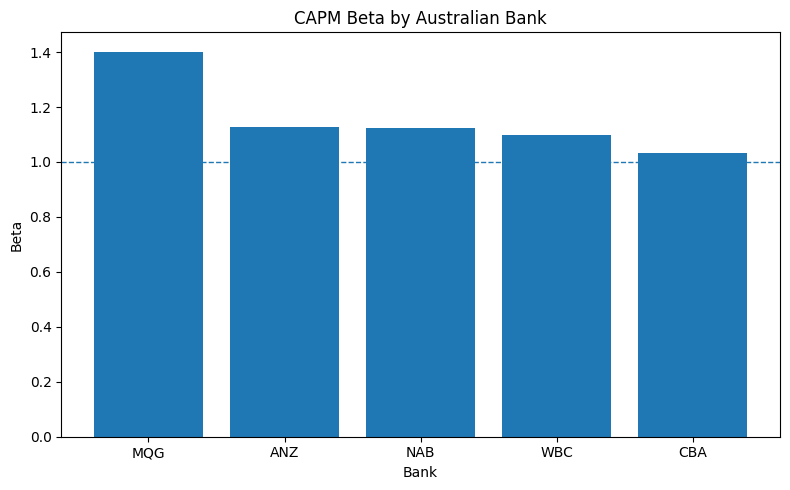

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(
    capm_summary.index,
    capm_summary["Beta"]
)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("CAPM Beta by Australian Bank")
plt.ylabel("Beta")
plt.xlabel("Bank")
plt.tight_layout()
plt.show()


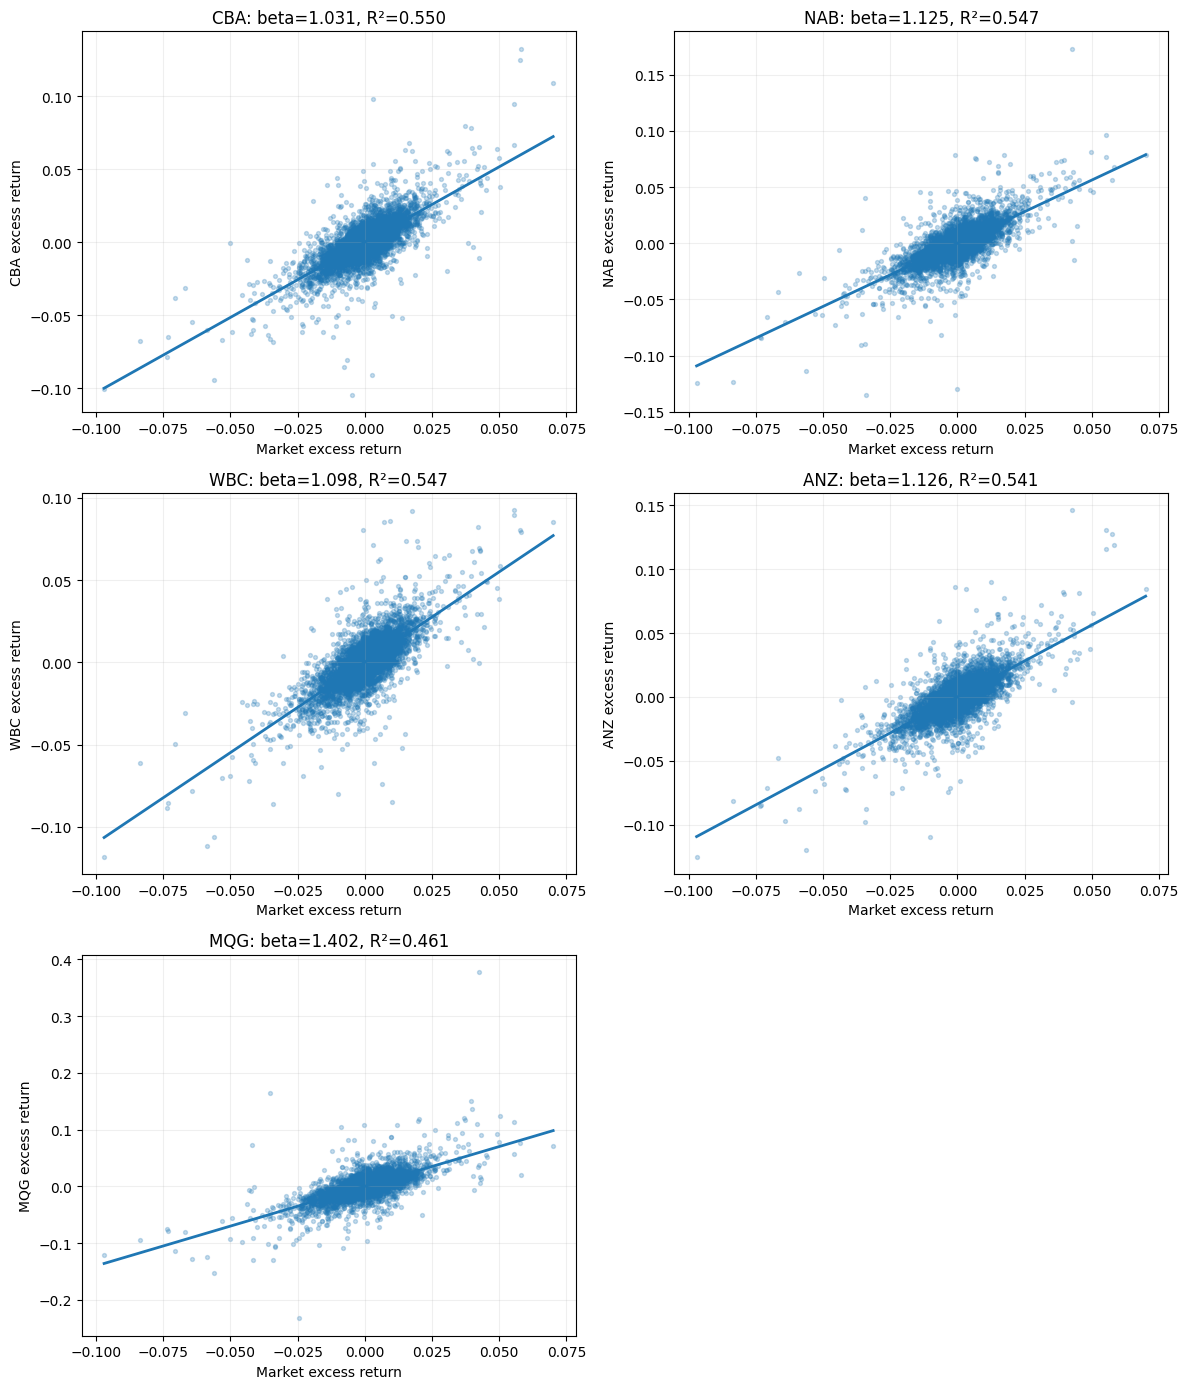

In [18]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 14)
)
axes = axes.flatten()

for i, bank in enumerate(bank_columns):
    ax = axes[i]
    x = capm_excess_returns["Market_Excess_Return"]
    y = capm_excess_returns[bank]
    model = capm_results[bank]
    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.25
    )
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = (
        model.params["const"]
        + model.params["Market_Excess_Return"] * x_line
    )
    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )
    ax.set_title(
        f"{bank}: beta={model.params['Market_Excess_Return']:.3f}, "
        f"R²={model.rsquared:.3f}"
    )
    ax.set_xlabel("Market excess return")
    ax.set_ylabel(f"{bank} excess return")
    ax.grid(alpha=0.2)

axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [19]:
capm_summary.to_csv(
    "../data/processed/capm_summary.csv"
)
print("Saved:", "../data/processed/capm_summary.csv")

Saved: ../data/processed/capm_summary.csv


In [20]:
capm_regression_results = []
for bank in bank_columns:
    model = capm_results[bank]
    beta_ci = model.conf_int().loc["Market_Excess_Return"]

    capm_regression_results.append({
        "Bank": bank,
        "Alpha": model.params["const"],
        "Alpha_t_stat": model.tvalues["const"],
        "Alpha_p_value": model.pvalues["const"],
        "Beta": model.params["Market_Excess_Return"],
        "Beta_t_stat": model.tvalues["Market_Excess_Return"],
        "Beta_p_value": model.pvalues["Market_Excess_Return"],
        "Beta_CI_95_Lower": beta_ci.iloc[0],
        "Beta_CI_95_Upper": beta_ci.iloc[1],
        "R_Squared": model.rsquared,
        "N_Observations": int(model.nobs)
    })

capm_regression_results = pd.DataFrame(capm_regression_results).set_index("Bank")
print(capm_regression_results.round(6))
capm_regression_results.to_csv(
    "../data/processed/capm_regression_results.csv"
)

print("Saved: ../data/processed/capm_regression_results.csv")


         Alpha  Alpha_t_stat  Alpha_p_value      Beta  Beta_t_stat  \
Bank                                                                 
CBA   0.000201      1.714020       0.086574  1.031104    87.632674   
NAB  -0.000034     -0.265579       0.790572  1.125139    87.146500   
WBC   0.000075      0.597709       0.550056  1.098205    87.165510   
ANZ  -0.000034     -0.263988       0.791798  1.126106    86.092220   
MQG   0.000219      1.152496       0.249161  1.401767    73.426438   

      Beta_p_value  Beta_CI_95_Lower  Beta_CI_95_Upper  R_Squared  \
Bank                                                                
CBA            0.0          1.008038          1.054170   0.549694   
NAB            0.0          1.099829          1.150449   0.546938   
WBC            0.0          1.073507          1.122904   0.547046   
ANZ            0.0          1.100464          1.151747   0.540899   
MQG            0.0          1.364342          1.439191   0.461500   

      N_Observations  
Ba

In [21]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nAbsolute path of ../data/processed:")
print(os.path.abspath("../data/processed"))

Current working directory:
c:\Users\user\Desktop\Australian-bank-risk-analytics\notebooks

Absolute path of ../data/processed:
c:\Users\user\Desktop\Australian-bank-risk-analytics\data\processed


In [22]:
# crisis periods for analysis
crisis_periods = {
    "GFC": ("2007-10-01", "2009-03-31"),
    "COVID": ("2020-02-19", "2021-06-30"),
    "Rate Hikes": ("2022-05-03", "2023-11-07")
}

crisis_capm_rows = []

for period, (start_date, end_date) in crisis_periods.items():
    crisis = capm_excess_returns.loc[start_date:end_date].copy()

    for bank in bank_columns:
        crisis_pair = crisis[[bank, "Market_Excess_Return"]].dropna()

        if len(crisis_pair) < 30:
            continue

        y = crisis_pair[bank]
        X = sm.add_constant(crisis_pair[["Market_Excess_Return"]])
        model = sm.OLS(y, X).fit()
        beta_ci = model.conf_int().loc["Market_Excess_Return"]

        crisis_capm_rows.append({
            "Period": period,
            "Bank": bank,
            "Alpha": model.params["const"],
            "Alpha_t_stat": model.tvalues["const"],
            "Alpha_p_value": model.pvalues["const"],
            "Beta": model.params["Market_Excess_Return"],
            "Beta_t_stat": model.tvalues["Market_Excess_Return"],
            "Beta_p_value": model.pvalues["Market_Excess_Return"],
            "Beta_CI_95_Lower": beta_ci.iloc[0],
            "Beta_CI_95_Upper": beta_ci.iloc[1],
            "R_Squared": model.rsquared,
            "N_Observations": int(model.nobs)
        })

crisis_capm_results = pd.DataFrame(crisis_capm_rows)

print(crisis_capm_results.round(6))

crisis_capm_results.to_csv(
    "../data/processed/crisis_capm_results.csv",
    index=False
)

crisis_beta_table = crisis_capm_results.pivot(
    index="Bank", columns="Period", values="Beta"
)
crisis_beta_table.to_csv(
    "../data/processed/crisis_beta_table.csv"
)

full_sample_beta = capm_summary["Beta"]
crisis_beta_comparison = crisis_capm_results.pivot(
    index="Bank", columns="Period", values="Beta"
).copy()
crisis_beta_comparison["Full_Sample_Beta"] = full_sample_beta.reindex(
    crisis_beta_comparison.index
)

for period in crisis_periods:
    crisis_beta_comparison[f"{period}_Minus_Full"] = (
        crisis_beta_comparison[period]
        - crisis_beta_comparison["Full_Sample_Beta"]
    )

crisis_beta_comparison.to_csv(
    "../data/processed/crisis_beta_comparison.csv"
)

print("Saved crisis CAPM files:")
print("- ../data/processed/crisis_capm_results.csv")
print("- ../data/processed/crisis_beta_table.csv")
print("- ../data/processed/crisis_beta_comparison.csv")


        Period Bank     Alpha  Alpha_t_stat  Alpha_p_value      Beta  \
0          GFC  CBA  0.000644      0.628365       0.530144  1.036910   
1          GFC  NAB  0.000488      0.442460       0.658410  1.214136   
2          GFC  WBC  0.000961      0.949313       0.343068  1.109427   
3          GFC  ANZ  0.000613      0.543924       0.586815  1.215558   
4          GFC  MQG  0.000781      0.401548       0.688244  1.707561   
5        COVID  CBA  0.000288      0.493939       0.621665  1.188245   
6        COVID  NAB -0.000076     -0.100599       0.919927  1.247687   
7        COVID  WBC  0.000011      0.014276       0.988618  1.240397   
8        COVID  ANZ  0.000213      0.273842       0.784370  1.335208   
9        COVID  MQG  0.000176      0.220902       0.825299  1.264645   
10  Rate Hikes  CBA  0.000082      0.194324       0.846025  0.912747   
11  Rate Hikes  NAB -0.000070     -0.147854       0.882536  0.951893   
12  Rate Hikes  WBC -0.000072     -0.145356       0.884506  0.89